# Fraud Detection with governed-rank

Fraud review teams have limited capacity. The ML model ranks transactions by fraud
probability — but a $50,000 fraudulent wire transfer matters more than a $5 fraudulent
candy purchase.

This notebook shows how `govern()` steers a fraud review queue toward **high-value
suspicious transactions** without overriding the base model's confident fraud calls.

**What you'll see:**
- The review queue problem (fraud probability \u2260 business impact)
- Why naive impact-weighting floods the queue with false positives
- How MOSAIC steers toward high-value fraud only where the model is uncertain
- Tiered gating: auto-block / step-up auth / allow

In [1]:
!pip install -q governed-rank


[notice] A new release of pip is available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from mosaic import govern

# ---------------------------------------------------------------------------
# Simulate a fraud detection review queue
# ---------------------------------------------------------------------------
# An ML model scores transactions by fraud probability. The business also
# cares about transaction VALUE: catching a $50K fraud matters more than
# catching a $5 fraud. We want to steer the queue toward high-impact fraud.

np.random.seed(42)
n = 300

# Transaction amounts (log-normal: mostly small, some very large)
amounts = np.exp(np.random.normal(4.0, 1.5, n))
amounts = np.clip(amounts, 5, 50000).astype(int)

# Fraud probability from ML model (Beta-distributed: most are low-risk)
fraud_prob = np.random.beta(1.5, 8, n)
# Small positive correlation with amount (larger transactions slightly riskier)
fraud_prob = fraud_prob + 0.1 * np.log1p(amounts) / np.log1p(50000)
fraud_prob = np.clip(fraud_prob, 0.01, 0.99)

# Ground truth: is this actually fraud?
is_fraud = (np.random.rand(n) < fraud_prob).astype(int)

# Business impact signal (log-scaled amount: higher = more important to catch)
impact = np.log1p(amounts) / np.log1p(50000)

r = np.corrcoef(fraud_prob, impact)[0, 1]
fraud_value = amounts[is_fraud == 1].sum()
print(f"Transactions:        {n}")
print(f"Fraud rate:          {is_fraud.mean():.1%} ({is_fraud.sum()} cases)")
print(f"Amount range:        ${amounts.min():,} \u2014 ${amounts.max():,}")
print(f"Total fraud value:   ${fraud_value:,}")
print(f"Corr(fraud, impact): {r:.3f}")

Transactions:        300
Fraud rate:          19.3% (58 cases)
Amount range:        $5 — $17,660
Total fraud value:   $7,635
Corr(fraud, impact): 0.131


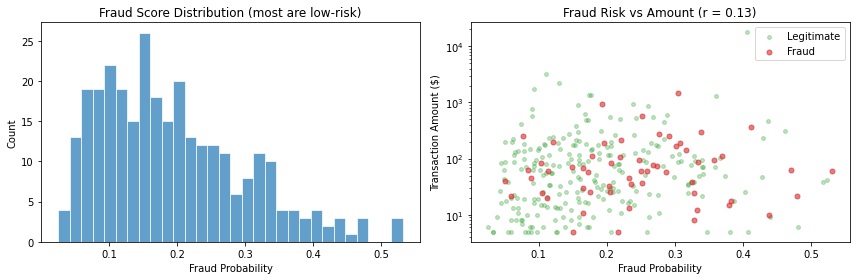

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(fraud_prob, bins=30, color='#1f77b4', alpha=0.7, edgecolor='white')
ax.set_xlabel('Fraud Probability')
ax.set_ylabel('Count')
ax.set_title('Fraud Score Distribution (most are low-risk)')

ax = axes[1]
legit = is_fraud == 0
ax.scatter(fraud_prob[legit], amounts[legit],
           alpha=0.3, s=15, c='#2ca02c', label='Legitimate')
ax.scatter(fraud_prob[~legit], amounts[~legit],
           alpha=0.6, s=25, c='#d62728', label='Fraud')
ax.set_xlabel('Fraud Probability')
ax.set_ylabel('Transaction Amount ($)')
ax.set_yscale('log')
ax.set_title(f'Fraud Risk vs Amount (r = {r:.2f})')
ax.legend()

plt.tight_layout()
plt.show()

## 1. Base Review Queue: Fraud Probability Only

The base model ranks transactions by fraud probability — highest first.
The review team works top-down through this queue.

**Problem**: the base model ignores business impact. Small-dollar fraud
ranks above large-dollar fraud when the model score is higher. The team
wastes time on low-value cases while high-value fraud sits unreviewed.

In [4]:
# Take top 100 transactions by fraud probability as the review queue.
# govern()'s max_rank=50 covers the top half of the queue.
top_idx = np.argsort(-fraud_prob)[:100]

# Steering weight: scales impact signal relative to fraud_prob range.
steer_weight = 1.0

base_scores  = {int(i): float(fraud_prob[i]) for i in top_idx}
steer_scores = {int(i): steer_weight * float(impact[i]) for i in top_idx}
amt_lookup   = {int(i): int(amounts[i]) for i in top_idx}
fraud_lookup = {int(i): int(is_fraud[i]) for i in top_idx}

base_order = sorted(base_scores, key=lambda x: -base_scores[x])

print("BASE REVIEW QUEUE (top 20 by fraud probability)")
print("=" * 70)
base_value_20 = 0
for rank, idx in enumerate(base_order[:20]):
    tag = "  FRAUD" if fraud_lookup[idx] else ""
    if fraud_lookup[idx]:
        base_value_20 += amt_lookup[idx]
    print(f"  {rank+1:2d}. Txn {idx:3d}  fraud_p={base_scores[idx]:.3f}"
          f"  amount=${amt_lookup[idx]:>7,}{tag}")

base_fraud_20 = sum(1 for i in base_order[:20] if fraud_lookup[i])
print(f"\nFraud caught in top 20: {base_fraud_20}/20")
print(f"Fraud value caught:    ${base_value_20:,}")

# Show high-value fraud the base model ranks too low
print("\nHigh-value fraud OUTSIDE top 20:")
missed = 0
for idx in base_order[20:]:
    if fraud_lookup[idx] and amt_lookup[idx] > 500:
        rank = base_order.index(idx) + 1
        print(f"  Rank {rank}. Txn {idx:3d}  fraud_p={base_scores[idx]:.3f}"
              f"  amount=${amt_lookup[idx]:>7,}  MISSED")
        missed += 1
        if missed >= 5:
            break

BASE REVIEW QUEUE (top 20 by fraud probability)
   1. Txn  22  fraud_p=0.531  amount=$     60  FRAUD
   2. Txn 104  fraud_p=0.523  amount=$     42
   3. Txn  21  fraud_p=0.518  amount=$     38
   4. Txn 100  fraud_p=0.480  amount=$      6
   5. Txn 277  fraud_p=0.479  amount=$     22  FRAUD
   6. Txn  78  fraud_p=0.471  amount=$     62  FRAUD
   7. Txn 162  fraud_p=0.462  amount=$    310
   8. Txn 158  fraud_p=0.440  amount=$      9
   9. Txn 227  fraud_p=0.438  amount=$     10  FRAUD
  10. Txn 270  fraud_p=0.437  amount=$    474
  11. Txn  91  fraud_p=0.430  amount=$    233
  12. Txn 172  fraud_p=0.428  amount=$     48
  13. Txn 256  fraud_p=0.412  amount=$    365  FRAUD
  14. Txn 262  fraud_p=0.407  amount=$      5
  15. Txn 209  fraud_p=0.406  amount=$ 17,660
  16. Txn 291  fraud_p=0.403  amount=$     26
  17. Txn 257  fraud_p=0.386  amount=$     18
  18. Txn 228  fraud_p=0.382  amount=$     18  FRAUD
  19. Txn 142  fraud_p=0.381  amount=$      5
  20. Txn 188  fraud_p=0.379  amount

## 2. Naive Fix: Add Impact Weight

The obvious approach: add business impact to the fraud score so high-value
transactions rank higher in the review queue.

```
final = fraud_prob + 0.5 * business_impact
```

**Problem**: this also boosts high-value *legitimate* transactions into the
review queue — flooding it with false positives and wasting reviewer time.

In [5]:
# Naive: fraud_prob + weight * impact
naive_weight = 0.5
naive_scores = {i: base_scores[i] + naive_weight * float(impact[i])
                for i in base_scores}
naive_order = sorted(naive_scores, key=lambda x: -naive_scores[x])

tau_naive, _ = kendalltau(
    [base_order.index(i) for i in base_order],
    [naive_order.index(i) for i in base_order]
)

print("NAIVE QUEUE (top 20: fraud_prob + 0.5 \u00d7 impact)")
print("=" * 70)
naive_value_20 = 0
for rank, idx in enumerate(naive_order[:20]):
    tag = "  FRAUD" if fraud_lookup[idx] else ""
    if fraud_lookup[idx]:
        naive_value_20 += amt_lookup[idx]
    print(f"  {rank+1:2d}. Txn {idx:3d}  fraud_p={base_scores[idx]:.3f}"
          f"  amount=${amt_lookup[idx]:>7,}  naive={naive_scores[idx]:.3f}{tag}")

naive_fraud_20 = sum(1 for i in naive_order[:20] if fraud_lookup[i])
print(f"\nFraud caught: {naive_fraud_20}/20  Value: ${naive_value_20:,}")
print(f"Tau vs base: {tau_naive:.3f}  Quality: {100*(1+tau_naive)/2:.1f}%")

# Count false positives: legitimate high-value transactions pulled into top 20
naive_fp = sum(1 for i in naive_order[:20]
               if not fraud_lookup[i] and amt_lookup[i] > 1000)
base_fp  = sum(1 for i in base_order[:20]
               if not fraud_lookup[i] and amt_lookup[i] > 1000)
print(f"\nHigh-value false positives (>$1K) in top 20: "
      f"Base={base_fp}, Naive={naive_fp}")

NAIVE QUEUE (top 20: fraud_prob + 0.5 × impact)
   1. Txn 209  fraud_p=0.406  amount=$ 17,660  naive=0.858
   2. Txn 162  fraud_p=0.462  amount=$    310  naive=0.727
   3. Txn 270  fraud_p=0.437  amount=$    474  naive=0.722
   4. Txn  22  fraud_p=0.531  amount=$     60  naive=0.721  FRAUD
   5. Txn 104  fraud_p=0.523  amount=$     42  naive=0.697
   6. Txn 252  fraud_p=0.361  amount=$  1,317  naive=0.693
   7. Txn  21  fraud_p=0.518  amount=$     38  naive=0.687
   8. Txn 256  fraud_p=0.412  amount=$    365  naive=0.685  FRAUD
   9. Txn  91  fraud_p=0.430  amount=$    233  naive=0.682
  10. Txn  78  fraud_p=0.471  amount=$     62  naive=0.663  FRAUD
  11. Txn 125  fraud_p=0.305  amount=$  1,459  naive=0.642  FRAUD
  12. Txn 277  fraud_p=0.479  amount=$     22  naive=0.624  FRAUD
  13. Txn 172  fraud_p=0.428  amount=$     48  naive=0.608
  14. Txn 118  fraud_p=0.338  amount=$    303  naive=0.602  FRAUD
  15. Txn 133  fraud_p=0.369  amount=$    111  naive=0.587  FRAUD
  16. Txn 282  fra

## 3. MOSAIC: Prioritize High-Value Fraud

`govern()` orthogonalizes the impact signal against fraud probability before
steering. The remaining impact signal can only reorder transactions where the
fraud model is uncertain — it cannot override confident fraud calls.

- **High-confidence fraud** stays at the top (protected by budget)
- **High-confidence legitimate** stays at the bottom
- **Uncertain middle** gets reordered by business impact

In [6]:
result = govern(base_scores, steer_scores, budget=0.30)

mosaic_order = result.ranked_items

tau_mosaic, _ = kendalltau(
    [base_order.index(i) for i in base_order],
    [mosaic_order.index(i) for i in base_order]
)

print("MOSAIC QUEUE (top 20)")
print("=" * 70)
mosaic_value_20 = 0
for rank, idx in enumerate(mosaic_order[:20]):
    tag = "  FRAUD" if fraud_lookup[idx] else ""
    if fraud_lookup[idx]:
        mosaic_value_20 += amt_lookup[idx]
    print(f"  {rank+1:2d}. Txn {idx:3d}  fraud_p={base_scores[idx]:.3f}"
          f"  amount=${amt_lookup[idx]:>7,}{tag}")

mosaic_fraud_20 = sum(1 for i in mosaic_order[:20] if fraud_lookup[i])
print(f"\nFraud caught: {mosaic_fraud_20}/20  Value: ${mosaic_value_20:,}")
print(f"Tau vs base: {tau_mosaic:.3f}  Quality: {100*(1+tau_mosaic)/2:.1f}%")
print(f"Projection coefficient: {result.projection_coeff:.4f}")
print(f"Protected edges: {result.n_protected_edges}")
print(f"Active constraints: {result.n_active_constraints}")

MOSAIC QUEUE (top 20)
   1. Txn 209  fraud_p=0.406  amount=$ 17,660
   2. Txn 270  fraud_p=0.437  amount=$    474
   3. Txn 125  fraud_p=0.305  amount=$  1,459  FRAUD
   4. Txn  91  fraud_p=0.430  amount=$    233
   5. Txn  22  fraud_p=0.531  amount=$     60  FRAUD
   6. Txn 165  fraud_p=0.367  amount=$    101
   7. Txn 252  fraud_p=0.361  amount=$  1,317
   8. Txn 104  fraud_p=0.523  amount=$     42
   9. Txn 277  fraud_p=0.479  amount=$     22  FRAUD
  10. Txn  78  fraud_p=0.471  amount=$     62  FRAUD
  11. Txn 162  fraud_p=0.462  amount=$    310
  12. Txn  21  fraud_p=0.518  amount=$     38
  13. Txn 172  fraud_p=0.428  amount=$     48
  14. Txn 256  fraud_p=0.412  amount=$    365  FRAUD
  15. Txn  31  fraud_p=0.261  amount=$    878
  16. Txn 282  fraud_p=0.288  amount=$    589
  17. Txn 118  fraud_p=0.338  amount=$    303  FRAUD
  18. Txn 106  fraud_p=0.238  amount=$    924
  19. Txn 122  fraud_p=0.284  amount=$    447
  20. Txn  71  fraud_p=0.267  amount=$    548

Fraud caught: 6

## 4. Head-to-Head: Value Captured

The key metric for fraud teams isn't just precision — it's **fraud value captured**.
Catching a $50K fraud is worth more than catching ten $5 frauds.

| Metric | What it measures |
|--------|------------------|
| Fraud/K | Actual fraud cases in top K of queue |
| Value/K | Total dollar value of fraud caught in top K |
| Tau | Rank correlation with base model (1.0 = same ordering) |
| Quality | (1 + tau) / 2 — fraction of pairwise orderings preserved |

In [7]:
print(f"{'':>8} {'Fraud/20':>9} {'Value/20':>12} {'Fraud/50':>9} {'Value/50':>12} {'Tau':>7} {'Quality':>8}")
print("-" * 72)

for name, order, tau in [
    ("Base",   base_order,   1.0),
    ("Naive",  naive_order,  tau_naive),
    ("MOSAIC", mosaic_order, tau_mosaic),
]:
    f20 = sum(1 for i in order[:20] if fraud_lookup[i])
    v20 = sum(amt_lookup[i] for i in order[:20] if fraud_lookup[i])
    f50 = sum(1 for i in order[:50] if fraud_lookup[i])
    v50 = sum(amt_lookup[i] for i in order[:50] if fraud_lookup[i])
    q = (1 + tau) / 2
    print(f"{name:>8} {f20:>9} ${v20:>11,} {f50:>9} ${v50:>11,} {tau:>7.3f} {100*q:>7.1f}%")

          Fraud/20     Value/20  Fraud/50     Value/50     Tau  Quality
------------------------------------------------------------------------
    Base         7 $        552        17 $      1,562   1.000   100.0%
   Naive         8 $      2,477        17 $      4,193   0.518    75.9%
  MOSAIC         6 $      2,271        15 $      4,165   0.336    66.8%


## 5. Tiered Gating

Production fraud systems use **tiered actions**, not binary approve/reject:

| Tier | Queue Position | Action |
|------|---------------|--------|
| **BLOCK** | Top 10% | Auto-decline — highest combined risk |
| **REVIEW** | Next 20% | Manual review — step-up authentication |
| **ALLOW** | Bottom 70% | Auto-approve — low risk |

**Precision** = actual fraud / total transactions in tier.
Higher precision in BLOCK means fewer wasted auto-declines on legitimate transactions.

In [8]:
n_items = len(base_order)
tiers = [
    ("BLOCK",  0, int(0.10 * n_items)),
    ("REVIEW", int(0.10 * n_items), int(0.30 * n_items)),
    ("ALLOW",  int(0.30 * n_items), n_items),
]

print(f"{'Tier':<8} {'Method':<8} {'Items':>6} {'Fraud':>6} {'Precision':>10} {'Value':>12}")
print("-" * 56)

for tier_name, start, end in tiers:
    for method, order in [("Base", base_order), ("Naive", naive_order), ("MOSAIC", mosaic_order)]:
        tier_items = order[start:end]
        tier_fraud = sum(1 for i in tier_items if fraud_lookup[i])
        tier_total = end - start
        precision = tier_fraud / tier_total if tier_total > 0 else 0
        value = sum(amt_lookup[i] for i in tier_items if fraud_lookup[i])
        print(f"{tier_name:<8} {method:<8} {tier_total:>6} {tier_fraud:>6} {precision:>10.1%} ${value:>11,}")
    print()

# Fraud slipping through the ALLOW tier
print("Fraud slipping through ALLOW tier (unreviewed):")
for method, order in [("Base", base_order), ("Naive", naive_order), ("MOSAIC", mosaic_order)]:
    allow_items = order[int(0.30 * n_items):]
    slipped = sum(1 for i in allow_items if fraud_lookup[i])
    slipped_value = sum(amt_lookup[i] for i in allow_items if fraud_lookup[i])
    print(f"  {method:<8} {slipped} fraud cases, ${slipped_value:,} in value")

Tier     Method    Items  Fraud  Precision        Value
--------------------------------------------------------
BLOCK    Base         10      4      40.0% $        154
BLOCK    Naive        10      3      30.0% $        487
BLOCK    MOSAIC       10      4      40.0% $      1,603

REVIEW   Base         20      5      25.0% $        604
REVIEW   Naive        20      8      40.0% $      2,443
REVIEW   MOSAIC       20     10      50.0% $      2,476

ALLOW    Base         70     23      32.9% $      4,088
ALLOW    Naive        70     21      30.0% $      1,916
ALLOW    MOSAIC       70     18      25.7% $        767

Fraud slipping through ALLOW tier (unreviewed):
  Base     23 fraud cases, $4,088 in value
  Naive    21 fraud cases, $1,916 in value
  MOSAIC   18 fraud cases, $767 in value


## 6. Budget Sweep

The budget knob controls how much the review queue deviates from pure
fraud-probability ordering:

| Budget | Meaning |
|--------|--------|
| 0.00 | Maximum impact steering — reorder freely |
| 0.30 | Protect 30% most confident fraud calls (default) |
| 1.00 | No steering — pure fraud-probability queue |

In [9]:
print(f"{'Budget':>8} {'Fraud/20':>9} {'Value/20':>12} {'Tau':>8} {'Quality':>9}")
print("-" * 50)

for b in [0.00, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00]:
    r = govern(base_scores, steer_scores, budget=b)
    order = r.ranked_items
    f20 = sum(1 for i in order[:20] if fraud_lookup[i])
    v20 = sum(amt_lookup[i] for i in order[:20] if fraud_lookup[i])
    tau, _ = kendalltau(
        [base_order.index(i) for i in base_order],
        [order.index(i) for i in base_order]
    )
    q = (1 + tau) / 2
    print(f"{b:>8.2f} {f20:>9} ${v20:>11,} {tau:>8.3f} {100*q:>8.1f}%")

print("\nLower budget \u2192 more impact steering (higher-value fraud caught first).")
print("Higher budget \u2192 closer to pure fraud-probability ordering.")

  Budget  Fraud/20     Value/20      Tau   Quality
--------------------------------------------------
    0.00         7 $      2,930    0.326     66.3%
    0.10         7 $      2,930    0.332     66.6%
    0.20         7 $      2,841    0.338     66.9%
    0.30         6 $      2,271    0.336     66.8%
    0.50         7 $      2,841    0.356     67.8%
    0.70         6 $      2,538    0.401     70.1%
    1.00         6 $      1,978    0.582     79.1%

Lower budget → more impact steering (higher-value fraud caught first).
Higher budget → closer to pure fraud-probability ordering.


## Summary

| | Base Model | Naive Impact Boost | MOSAIC |
|---|---|---|---|
| **Ranks by** | Fraud probability only | fraud_prob + impact | Orthogonalized impact |
| **Problem** | Misses high-value fraud | Floods queue with FPs | — |
| **Impact steering** | None | Uncontrolled | Targeted at uncertain zone |
| **Quality control** | N/A | Weight parameter | Budget knob (smooth) |

**Key insight**: Naive impact-weighting boosts ALL high-value transactions —
including legitimate ones — into the review queue. MOSAIC orthogonalizes first,
so the impact signal can only reorder transactions where the fraud model is
uncertain. The model's most confident calls are protected.

```python
from mosaic import govern
result = govern(fraud_scores, impact_scores, budget=0.30)
```